In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

In [4]:
data = pd.read_csv("D:\BDA_0024\APS_LAB\datasets\Telco-Customer-Churn.csv")

In [5]:
print("Dataset Shape:", data.shape)


Dataset Shape: (7043, 21)


In [6]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
print(data.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [9]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# CREATE COPY

data_missing = data.copy()

print("Original dataset preserved.")
print("Working dataset shape:", data_missing.shape)

Original dataset preserved.
Working dataset shape: (7043, 21)


In [11]:
# INTRODUCE SYNTHETIC MISSING VALUES

np.random.seed(42)

columns_to_modify = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "InternetService",
    "PaymentMethod"
]

missing_percentage = 0.05

for column in columns_to_modify:
    
    missing_indices = np.random.choice(
        data_missing.index,
        size=int(missing_percentage * len(data_missing)),
        replace=False
    )
    
    data_missing.loc[
        missing_indices,
        column
    ] = np.nan

In [12]:
# CHECK SYNTHETIC MISSING VALUES

print("Missing values after synthetic modification:\n")

print(data_missing.isnull().sum())

print("\nTotal missing values:",
      data_missing.isnull().sum().sum())

Missing values after synthetic modification:

customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure              352
PhoneService          0
MultipleLines         0
InternetService     352
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract            352
PaperlessBilling      0
PaymentMethod       352
MonthlyCharges      352
TotalCharges        352
Churn                 0
dtype: int64

Total missing values: 2112


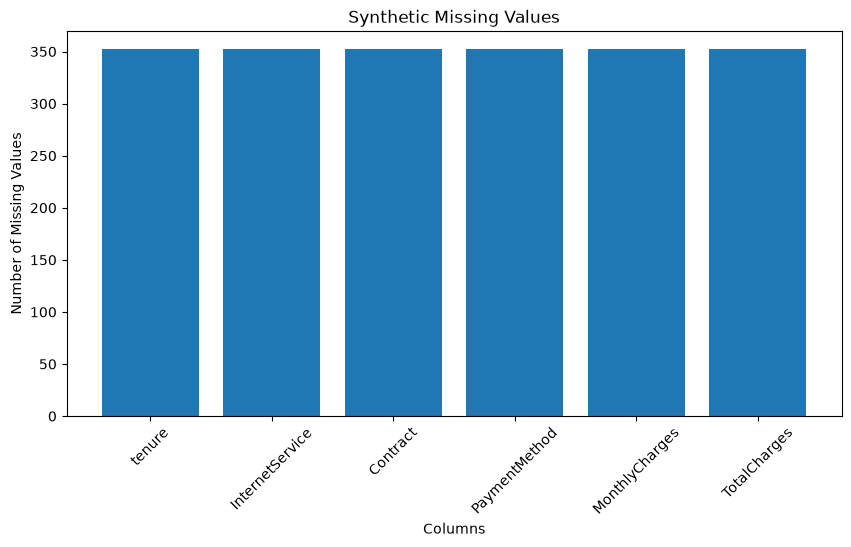

In [13]:
# MISSING VALUE VISUALIZATION

missing_counts = data_missing.isnull().sum()

missing_counts = missing_counts[
    missing_counts > 0
]

plt.figure(figsize=(10, 5))

plt.bar(
    missing_counts.index,
    missing_counts.values
)

plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.title("Synthetic Missing Values")

plt.xticks(rotation=45)

plt.show()

In [14]:
# CONVERT TOTALCHARGES TO NUMERIC

data_missing["TotalCharges"] = pd.to_numeric(
    data_missing["TotalCharges"],
    errors="coerce"
)

print(data_missing["TotalCharges"].dtype)

float64


In [16]:
# HANDLE NUMERICAL MISSING VALUES

numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numerical_columns:
    
    data_missing[column] = data_missing[column].fillna(
        data_missing[column].median()
    )

print("Numerical missing values handled.")

Numerical missing values handled.


In [17]:
# HANDLE CATEGORICAL MISSING VALUES

categorical_columns = [
    "Contract",
    "InternetService",
    "PaymentMethod"
]

for column in categorical_columns:
    
    data_missing[column] = data_missing[column].fillna(
        data_missing[column].mode()[0]
    )

print("Categorical missing values handled.")

Categorical missing values handled.


In [18]:
# FINAL NULL CHECK

print("Missing values after handling:\n")

print(data_missing.isnull().sum())

print("\nTotal missing values:",
      data_missing.isnull().sum().sum())

Missing values after handling:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0


In [19]:
data_missing.duplicated().sum()

np.int64(0)

In [20]:
# TARGET VARIABLE

print(data_missing["Churn"].value_counts())

print("\nPercentage distribution:")
print(
    data_missing["Churn"]
    .value_counts(normalize=True) * 100
)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


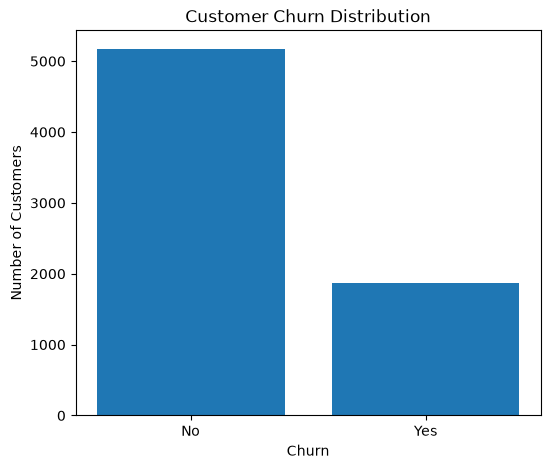

In [21]:
# CHURN DISTRIBUTION

churn_counts = data_missing["Churn"].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.show()

In [22]:
# CONVERT TARGET VARIABLE

data_missing["Churn"] = data_missing["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(data_missing["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [23]:
# CREATE FEATURES AND TARGET

X = data_missing.drop(
    columns=["customerID", "Churn"]
)

y = data_missing["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [24]:
# IDENTIFY CATEGORICAL FEATURES

categorical_features = X.select_dtypes(
    include=["object"]
).columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical features:")
print(numerical_features.tolist())

print("\nCategorical features:")
print(categorical_features.tolist())

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\bda\AppData\Local\Temp\ipykernel_1112\4234541191.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [25]:
# ONE-HOT ENCODING

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Shape after encoding:", X.shape)

X.head()

Shape after encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1.0,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34.0,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2.0,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45.0,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2.0,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [26]:
# CONVERT BOOLEAN TO INTEGER

X = X.astype(int)

print(X.dtypes.value_counts())

int64    30
Name: count, dtype: int64


In [27]:
# FINAL FEATURE CHECK

print("Total null values in X:",
      X.isnull().sum().sum())

print("Total null values in y:",
      y.isnull().sum())

Total null values in X: 0
Total null values in y: 0


In [28]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training size:", len(y_train))
print("Testing size:", len(y_test))

Training size: 5634
Testing size: 1409


In [29]:
# CLASS DISTRIBUTION BEFORE SMOTE

print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing class distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


In [30]:
# STANDARDIZATION

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [31]:
# LOGISTIC REGRESSION - BASELINE

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train
)

print("Baseline Logistic Regression trained.")

Baseline Logistic Regression trained.


In [32]:
# BASELINE PREDICTIONS

y_pred_lr = lr_model.predict(X_test_scaled)

y_prob_lr = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

In [33]:
# BASELINE MODEL EVALUATION

print("===== LOGISTIC REGRESSION WITHOUT SMOTE =====")

print("Accuracy :",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall   :",
      recall_score(y_test, y_pred_lr))

print("F1 Score :",
      f1_score(y_test, y_pred_lr))

===== LOGISTIC REGRESSION WITHOUT SMOTE =====
Accuracy : 0.7991483321504613
Precision: 0.645367412140575
Recall   : 0.5401069518716578
F1 Score : 0.5880640465793304


In [34]:
# CONFUSION MATRIX

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm_lr)

[[924 111]
 [172 202]]


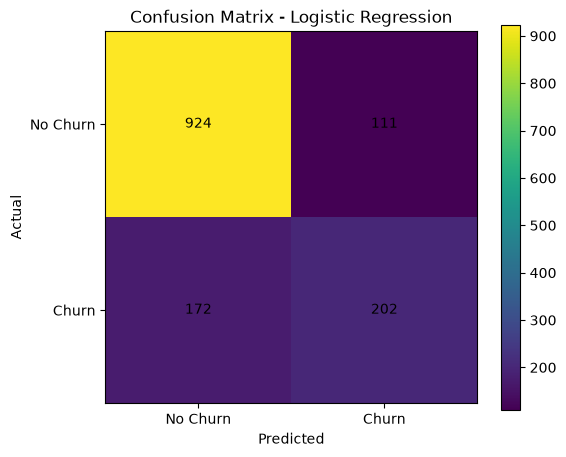

In [35]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_lr)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.yticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_lr[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [36]:
# APPLY SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [37]:
# LOGISTIC REGRESSION WITH SMOTE

lr_smote = LogisticRegression(
    max_iter=1000
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

print("SMOTE Logistic Regression trained.")

SMOTE Logistic Regression trained.


In [38]:
# SMOTE PREDICTIONS

y_pred_smote = lr_smote.predict(
    X_test_scaled
)

y_prob_smote = lr_smote.predict_proba(
    X_test_scaled
)[:, 1]

In [39]:
# SMOTE MODEL EVALUATION

print("===== LOGISTIC REGRESSION WITH SMOTE =====")

print("Accuracy :",
      accuracy_score(y_test, y_pred_smote))

print("Precision:",
      precision_score(y_test, y_pred_smote))

print("Recall   :",
      recall_score(y_test, y_pred_smote))

print("F1 Score :",
      f1_score(y_test, y_pred_smote))

===== LOGISTIC REGRESSION WITH SMOTE =====
Accuracy : 0.7359829666430092
Precision: 0.5017543859649123
Recall   : 0.7647058823529411
F1 Score : 0.6059322033898306


In [41]:
print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.50      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.74      0.75      1409



In [42]:
# SMOTE CONFUSION MATRIX

cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

print(cm_smote)

[[751 284]
 [ 88 286]]


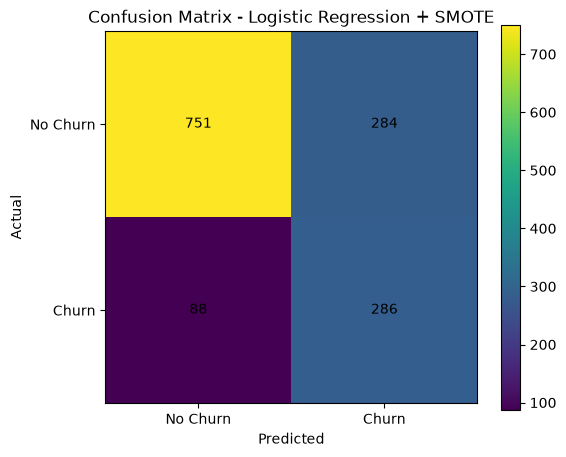

In [43]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_smote)

plt.title("Confusion Matrix - Logistic Regression + SMOTE")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.yticks(
    [0, 1],
    ["No Churn", "Churn"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_smote[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [44]:
# ==============================
# MODEL COMPARISON
# ==============================

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Logistic Regression + SMOTE"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_smote)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_smote)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_smote)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_smote)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7991,0.6454,0.5401,0.5881
1,Logistic Regression + SMOTE,0.7360,0.5018,0.7647,0.6059


In [45]:
# ==============================
# ROC - BASELINE MODEL
# ==============================

fpr_lr, tpr_lr, thresholds_lr = roc_curve(
    y_test,
    y_prob_lr
)

auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

print("Logistic Regression AUC:", auc_lr)

Logistic Regression AUC: 0.8355679557725595


In [46]:
# ==============================
# ROC - SMOTE MODEL
# ==============================

fpr_smote, tpr_smote, thresholds_smote = roc_curve(
    y_test,
    y_prob_smote
)

auc_smote = roc_auc_score(
    y_test,
    y_prob_smote
)

print("Logistic Regression + SMOTE AUC:",
      auc_smote)

Logistic Regression + SMOTE AUC: 0.8332945826551966


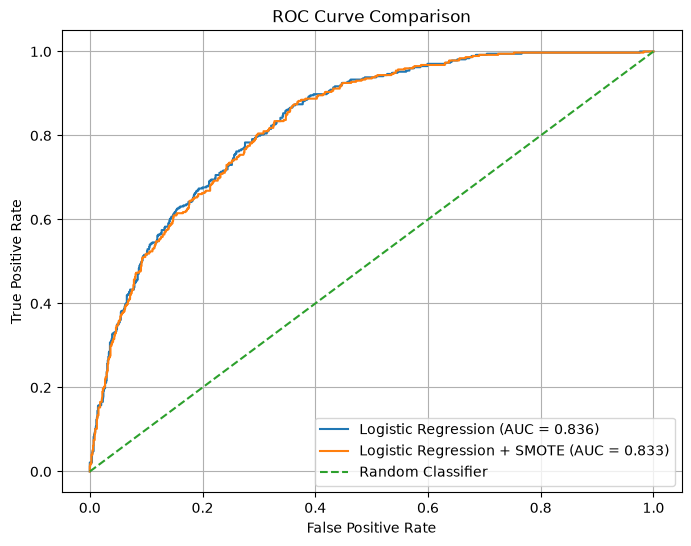

In [47]:
# ==============================
# ROC CURVE COMPARISON
# ==============================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_smote,
    tpr_smote,
    label=f"Logistic Regression + SMOTE (AUC = {auc_smote:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [49]:
# ==============================
# THRESHOLD ANALYSIS
# ==============================

thresholds = [
    0.10,
    0.30,
    0.50,
    0.70,
    0.90
]

threshold_results = []

for threshold in thresholds:

    predicted_churn = (
        y_prob_smote >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            predicted_churn
        ),

        "Precision": precision_score(
            y_test,
            predicted_churn,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predicted_churn,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test,
            predicted_churn,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(3)

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.1,0.502,0.346,0.987,0.513
1,0.3,0.654,0.428,0.912,0.583
2,0.5,0.736,0.502,0.765,0.606
3,0.7,0.786,0.601,0.575,0.587
4,0.9,0.746,0.767,0.061,0.114


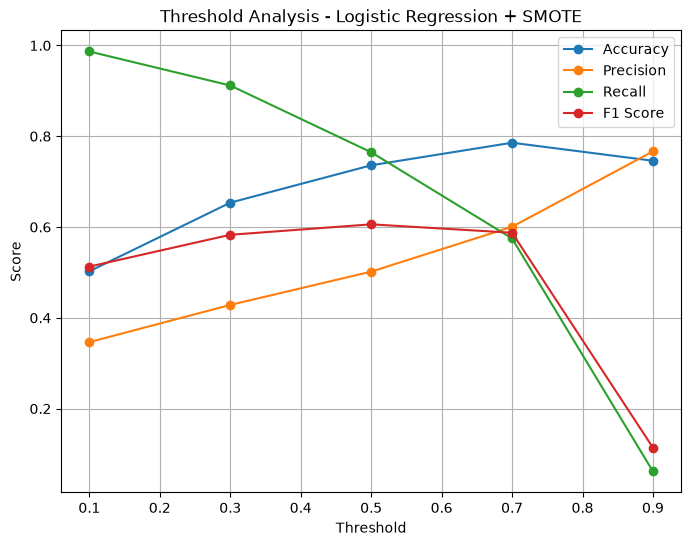

In [50]:
# ==============================
# THRESHOLD PERFORMANCE
# ==============================

plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Threshold Analysis - Logistic Regression + SMOTE"
)

plt.legend()
plt.grid(True)

plt.show()

Logistic Regression was used as the baseline model.

SMOTE was applied only to the training data
to balance the minority Churn class.

The test data was kept completely unchanged.

Compare Recall and F1 Score for the Churn class
to determine whether SMOTE improved detection
of customers likely to churn.

ROC-AUC is used to compare the overall
classification performance of both models.